In [1]:
# https://github.com/semework/GNNs_drug_discovery_regression

In [2]:
print('''

Comparison to the GCN approach you already have

The GCN you were just studying and ChemBERTa-77M-MTR are two complementary approaches to the same problem  : 

predicting a property / peoperties of a molecule:

GCN: builds the molecule's graph from atoms/bonds, message-passes, pools, and reads out. 

Tiny model (~13K params), trained from scratch on the dataset you give it. 

Lipo R² typically ~0.65–0.70.

ChemBERTa-77M-MTR: tokenizes the SMILES string, passes it through a transformer pre-trained on 77M molecules, and fine-tunes for your task. 

Bigger (~3M params), but the heavy lifting is already done by pre-training. 

On Lipo it typically reaches R² ~0.72–0.78 with proper fine-tuning.

''')



Comparison to the GCN approach you already have

The GCN you were just studying and ChemBERTa-77M-MTR are two complementary approaches to the same problem  : 

predicting a property / peoperties of a molecule:

GCN: builds the molecule's graph from atoms/bonds, message-passes, pools, and reads out. 

Tiny model (~13K params), trained from scratch on the dataset you give it. 

Lipo R² typically ~0.65–0.70.

ChemBERTa-77M-MTR: tokenizes the SMILES string, passes it through a transformer pre-trained on 77M molecules, and fine-tunes for your task. 

Bigger (~3M params), but the heavy lifting is already done by pre-training. 

On Lipo it typically reaches R² ~0.72–0.78 with proper fine-tuning.




In [3]:
## chemBERTa
## https://pharmanalytics.medium.com/using-chemical-language-transformer-model-for-molecular-property-prediction-regression-tasks-5d617aba4639
## https://pharmanalytics.medium.com/using-chemical-language-transformer-model-for-molecular-property-prediction-regression-part-2-d4f6c1a167f3 

In [4]:
# https://huggingface.co/DeepChem/ChemBERTa-77M-MTR
# https://deepchem.io/tutorials/transfer-learning-with-chemberta-transformers/

In [5]:
print('''

ChemBERTa-77M-MTR Overview

Aspect	: Description
Model	: ChemBERTa-77M-MTR
Developer	: DeepChem
Architecture	: Transformer-based RoBERTa model (a BERT variant)
Pretraining Data :	~77 million molecules from PubChem
Input Representation : SMILES strings
Typical Tasks :	Molecular property prediction, virtual screening, molecular embeddings, downstream fine-tuning
Framework :	Hugging Face Transformers + PyTorch

Key Facts

✅ ChemBERTa-77M-MTR is a real published model
The model exists and is publicly available through Hugging Face and DeepChem.

✅ Trained on ~77 million molecules
The model was pretrained on approximately 77 million molecular structures derived from PubChem.

✅ Uses a BERT-style transformer
ChemBERTa is based on RoBERTa, which is an optimized variant of BERT designed for masked-language modeling.

✅ Supports downstream fine-tuning

The pretrained embeddings can be fine-tuned for:

Solubility prediction
Toxicity prediction
Bioactivity prediction
Lipophilicity (logP/logD)
ADMET tasks
Molecular similarity tasks

''')



ChemBERTa-77M-MTR Overview

Aspect	: Description
Model	: ChemBERTa-77M-MTR
Developer	: DeepChem
Architecture	: Transformer-based RoBERTa model (a BERT variant)
Pretraining Data :	~77 million molecules from PubChem
Input Representation : SMILES strings
Typical Tasks :	Molecular property prediction, virtual screening, molecular embeddings, downstream fine-tuning
Framework :	Hugging Face Transformers + PyTorch

Key Facts

✅ ChemBERTa-77M-MTR is a real published model
The model exists and is publicly available through Hugging Face and DeepChem.

✅ Trained on ~77 million molecules
The model was pretrained on approximately 77 million molecular structures derived from PubChem.

✅ Uses a BERT-style transformer
ChemBERTa is based on RoBERTa, which is an optimized variant of BERT designed for masked-language modeling.

✅ Supports downstream fine-tuning

The pretrained embeddings can be fine-tuned for:

Solubility prediction
Toxicity prediction
Bioactivity prediction
Lipophilicity (logP/logD)
A

In [6]:
print('''

SMILES
   ↓
Tokenizer
   ↓
ChemBERTa Encoder
   ↓
CLS embedding
   ↓
Regression / Classification Head
   ↓
Property prediction

''')



SMILES
   ↓
Tokenizer
   ↓
ChemBERTa Encoder
   ↓
CLS embedding
   ↓
Regression / Classification Head
   ↓
Property prediction




In [7]:
print('''

Common down-stream tasks :

| Task                 | Example                       |
| -------------------- | ----------------------------- |
| Regression           | Solubility, logP, IC50        |
| Classification       | Toxic vs non-toxic            |
| Multi-task learning  | Simultaneous ADMET prediction |
| Embedding extraction | Molecular similarity search   |
| Transfer learning    | Small specialized datasets    |

''')



Common down-stream tasks :

| Task                 | Example                       |
| -------------------- | ----------------------------- |
| Regression           | Solubility, logP, IC50        |
| Classification       | Toxic vs non-toxic            |
| Multi-task learning  | Simultaneous ADMET prediction |
| Embedding extraction | Molecular similarity search   |
| Transfer learning    | Small specialized datasets    |




In [8]:
import sys
print(sys.executable)

/home/tanasa/anaconda3/envs/liana_py310/bin/python


In [9]:
# https://tdcommons.ai/single_pred_tasks/adme/
# https://tdcommons.ai/single_pred_tasks/adme/#lipophilicity-astrazeneca

# from tdc.single_pred import ADME

# Automatically downloads dataset
# data = ADME(name='Lipophilicity_AstraZeneca')

# Full dataframe
# df = data.get_data()

# Train/validation/test splits
# split = data.get_split()

# print(df.head())

# print("Train:", len(split['train']))
# print("Valid:", len(split['valid']))
# print("Test :", len(split['test']))

In [10]:
# import pandas as pd
# import numpy as np

# URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/Lipophilicity.csv"
# df = pd.read_csv(URL)

# Normalize the columns to match the rest of the pipeline ('Drug', 'Y')
# df = df.rename(columns={"smiles": "Drug", "exp": "Y"})[["Drug", "Y"]]

# print("Total molecules:", len(df))
# print(df.head())

# Shuffle reproducibly
# df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)

# 80 / 10 / 10 split
# n = len(df)
# n_train = int(n * 0.8)
# n_valid = int(n * 0.1)

# train_df = df.iloc[:n_train].reset_index(drop=True)
# valid_df = df.iloc[n_train:n_train + n_valid].reset_index(drop=True)
# test_df  = df.iloc[n_train + n_valid:].reset_index(drop=True)

# print(f"train={len(train_df)}  valid={len(valid_df)}  test={len(test_df)}")

In [11]:
# The Input(Dataset) Class tokenizes the SMILES strings and prepares them as input for the model. 
# It tokenizes the SMILES string using the tokenizer, applies padding and truncation to the maximum length, 
# and returns the input IDs, attention masks, and the labels.

In [12]:
# Common datasets ChemBERTa fine-tuning blog posts use:

# ADME(name='Lipophilicity_AstraZeneca') — logD, same task as your GCN.
# ADME(name='Solubility_AqSolDB') — aqueous solubility (logS).
# ADME(name='Caco2_Wang') — intestinal permeability.
# ADME(name='PPBR_AZ') — plasma protein binding.
# Tox(name='LD50_Zhu') — acute toxicity.

In [13]:
# https://pharmanalytics.medium.com/using-chemical-language-transformer-model-for-molecular-property-prediction-regression-tasks-5d617aba4639
# https://pharmanalytics.medium.com/using-chemical-language-transformer-model-for-molecular-property-prediction-regression-part-2-d4f6c1a167f3
# https://pharmanalytics.medium.com/using-chemical-language-transformer-model-for-molecular-property-prediction-regression-tasks-5d617aba4639

In [14]:
import deepchem
print("deepchem:", deepchem.__version__)
 
from rdkit import Chem
 
# Make BertViz importable
import sys
if 'bertviz_repo' not in sys.path:
    sys.path += ['bertviz_repo']
 
# Sanity-check Apex (mixed-precision tool)
# from apex import amp  # noqa: F401
 

Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'haiku'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


deepchem: 2.8.0


In [15]:
# git clone https://github.com/seyonechithrananda/bert-loves-chemistry.git

In [16]:
import sys
sys.path.insert(0, '/home/tanasa/CHEMISTRY_GNN/bert-loves-chemistry')

from chemberta.utils.molnet_dataloader import (
    load_molnet_dataset, write_molnet_dataset_for_chemprop,
)

In [17]:
print("DeepChem")
# https://arxiv.org/abs/2010.09885#

DeepChem


In [18]:
# https://deepchem.io/tutorials/transfer-learning-with-chemberta-transformers/ : DEEPCHEM

In [19]:
# !git clone https://github.com/NVIDIA/apex
# !cd /content/apex
# !pip install -v --no-cache-dir /content/apex
# !pip install transformers
# !pip install simpletransformers
# !pip install wandb
# !cd ..

# Test if NVIDIA apex training tool works
# from apex import amp

In [20]:
print('''

The model can predict masked/corrupted tokens within a SMILES sequence/molecule, 
allowing for variants of a molecule within discoverable chemical space to be predicted.

''')



The model can predict masked/corrupted tokens within a SMILES sequence/molecule, 
allowing for variants of a molecule within discoverable chemical space to be predicted.




In [21]:
print("What is a tokenizer?")

# The base classes PreTrainedTokenizer and PreTrainedTokenizerFast in HuggingFace 
# implements the common methods for encoding string inputs in model input
# The default tokenizer used by ChemBERTa, is a Byte-Pair-Encoder (BPE). 

What is a tokenizer?


In [22]:
# ---------------------------------------------------------------------------
# 1. Masked-token inference on SMILES
# ---------------------------------------------------------------------------
from transformers import (
    AutoModelForMaskedLM,
    AutoTokenizer,
    pipeline,
    RobertaModel,
    RobertaTokenizer,
)
from bertviz import head_view
 
model = AutoModelForMaskedLM.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k")
tokenizer = AutoTokenizer.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k")
fill_mask = pipeline('fill-mask', model=model, tokenizer=tokenizer)


Some weights of the model checkpoint at seyonec/PubChem10M_SMILES_BPE_450k were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


In [23]:
# To ensure our the ChemBERTa model demonstrates an understanding of chemical syntax and molecular structure, 
# we'll be testing it on predicting a masked token/character within the SMILES molecule for benzene.

# Predict masked token in benzene
smiles_mask = "C1=CC=CC<mask>C1"
smiles = "C1=CC=CC=C1"

masked_smi = fill_mask(smiles_mask)
for smi in masked_smi:
    print(smi)

{'score': 0.9755934476852417, 'token': 33, 'token_str': '=', 'sequence': 'C1=CC=CC=C1'}
{'score': 0.02092386782169342, 'token': 7, 'token_str': '#', 'sequence': 'C1=CC=CC#C1'}
{'score': 0.0007658937247470021, 'token': 21, 'token_str': '1', 'sequence': 'C1=CC=CC1C1'}
{'score': 0.00041297622374258935, 'token': 22, 'token_str': '2', 'sequence': 'C1=CC=CC2C1'}
{'score': 0.0002531911013647914, 'token': 352, 'token_str': '=[', 'sequence': 'C1=CC=CC=[C1'}


In [24]:
# The final branch, C1=CC=CC=C1 , is a benzene ring. 
# Since its a pretty common molecule, the model is easily able to predict the final double carbon bond with a score of 0.9

In [25]:
# Let's get a list of the top 5 predictions (including the target, Remdesivir), and visualize them

In [26]:
# ---------------------------------------------------------------------------
# Visualize the top-5 predictions with RDKit
# ---------------------------------------------------------------------------
import torch
import rdkit
import rdkit.Chem as Chem
from rdkit.Chem import rdFMCS
from matplotlib import colors
from rdkit.Chem import Draw
from rdkit.Chem.Draw import MolToImage
from PIL import Image
 
 
def get_mol(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    Chem.Kekulize(mol)
    return mol
 
 
def find_matches_one(mol, submol):
    """Find all matching atoms for submol within mol."""
    mols = [mol, submol]  # pairwise search
    res = rdFMCS.FindMCS(mols)
    mcsp = Chem.MolFromSmarts(res.smartsString)
    matches = mol.GetSubstructMatches(mcsp)
    return matches
 
 
def get_image(mol, atomset):
    hcolor = colors.to_rgb('green')
    if atomset is not None:
        img = MolToImage(
            mol, size=(600, 600), fitImage=True,
            highlightAtoms=atomset, highlightColor=hcolor,
        )
    else:
        img = MolToImage(mol, size=(400, 400), fitImage=True)
    return img
 


In [27]:
sequence = f"C1=CC=CC={tokenizer.mask_token}1"
substructure = "CC=CC"
image_list = []

C1=CC=CC=CC1
C1=CC=CC=CCC1
C1=CC=CC=CN1
C1=CC=CC=CCCC1
C1=CC=CC=CCO1


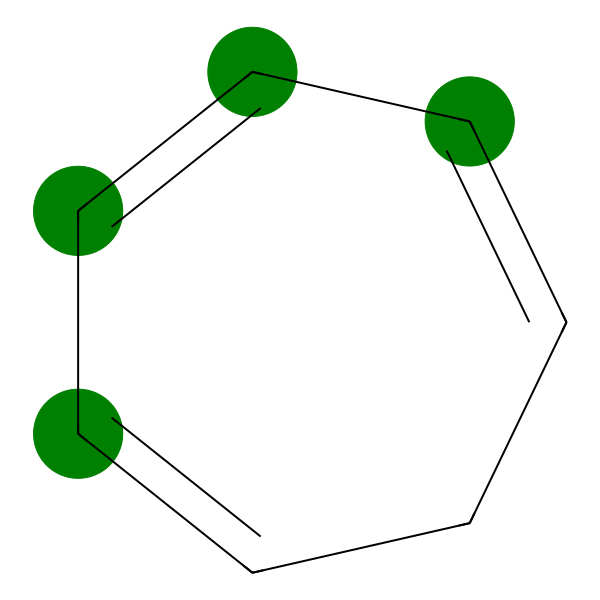

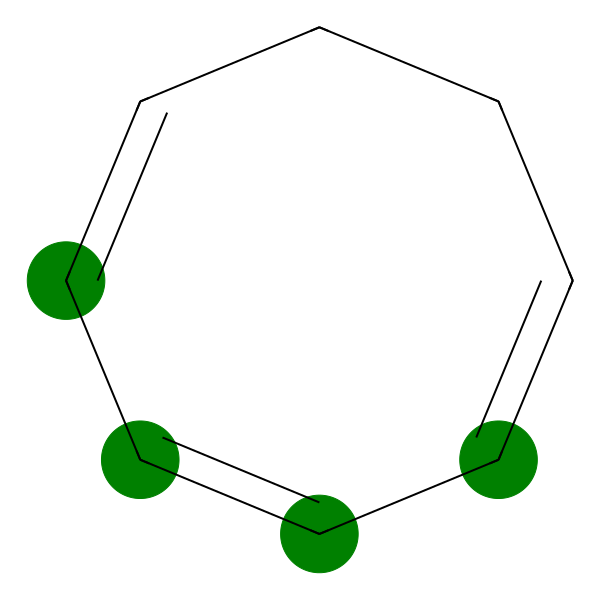

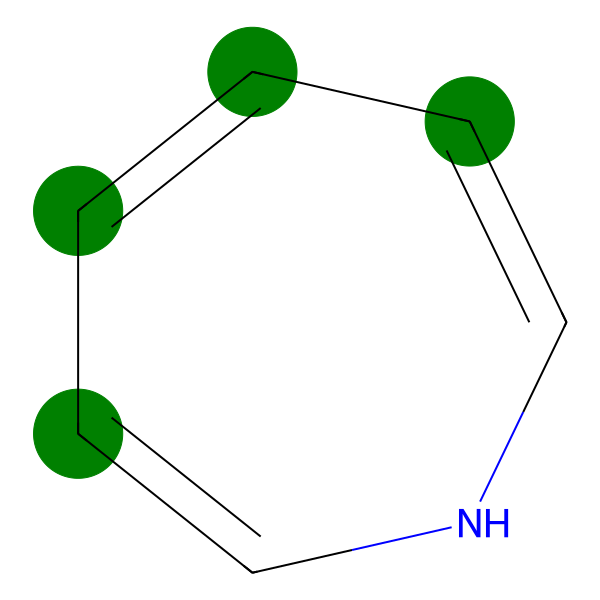

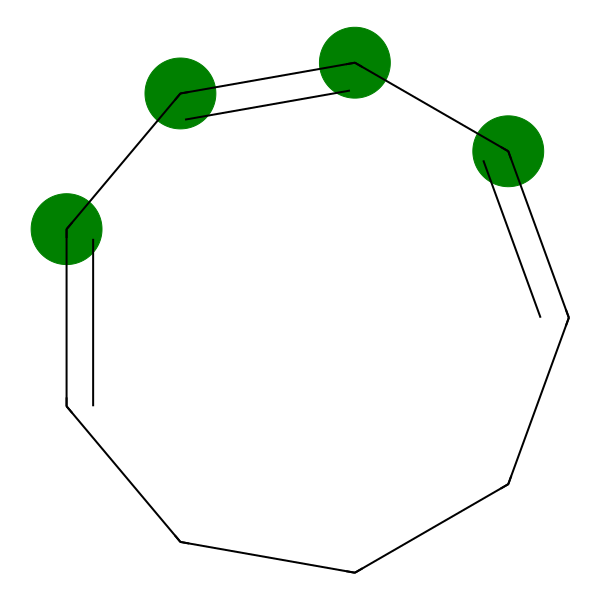

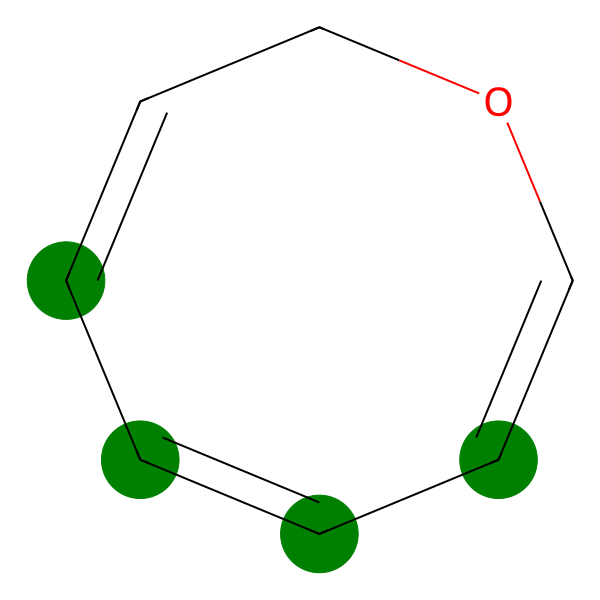

In [28]:
input_ids = tokenizer.encode(sequence, return_tensors="pt")
mask_token_index = torch.where(input_ids == tokenizer.mask_token_id)[1]
token_logits = model(input_ids)[0]
mask_token_logits = token_logits[0, mask_token_index, :]
top_5_tokens = torch.topk(mask_token_logits, 5, dim=1).indices[0].tolist()
 
for token in top_5_tokens:
    smi = sequence.replace(tokenizer.mask_token, tokenizer.decode([token]))
    print(smi)
    smi_mol = get_mol(smi)
    substructure_mol = get_mol(substructure)
    if smi_mol is None:  # skip chemically infeasible predictions
        continue
    Draw.MolToFile(smi_mol, smi + ".png")
    matches = find_matches_one(smi_mol, substructure_mol)
    atomset = list(matches[0])
    img = get_image(smi_mol, atomset)
    img.format = "PNG"
    image_list.append(img)
 
# In a notebook:
from IPython.display import display
for img in image_list:
    display(img)
 

In [29]:
print(''' 

What is attention ?

The attention mechanism extends the encoder–decoder model by operating on three learned representations for a SMILES sequence:

Query vector (Q)
Key vector (K)
Value vector (V)

These vectors function similarly to word embeddings in natural language processing, 
but are specialized for capturing relationships and compatibility between neighboring SMILES tokens.

The model computes attention by taking the dot product between:

the query vector of one token, 
and
the key vector of another token.

''')

 

What is attention ?

The attention mechanism extends the encoder–decoder model by operating on three learned representations for a SMILES sequence:

Query vector (Q)
Key vector (K)
Value vector (V)

These vectors function similarly to word embeddings in natural language processing, 
but are specialized for capturing relationships and compatibility between neighboring SMILES tokens.

The model computes attention by taking the dot product between:

the query vector of one token, 
and
the key vector of another token.




In [30]:
# BertViz is a tool for visualizing attention in the Transformer model, 
# supporting all models from the transformers library (BERT, GPT-2, XLNet, RoBERTa, XLM, CTRL, etc.). 
# It extends the Tensor2Tensor visualization tool by Llion Jones and the transformers library from HuggingFace.

# Using this tool, we can easily plug in ChemBERTa from the HuggingFace model hub and 
# visualize the attention patterns produced by one or more attention heads in a given transformer layer. 
# This is known as the attention-head view.

In [31]:
# https://www.kaggle.com/code/alexandervc/chembert2a-smiles-embeddings-for-beginners

In [32]:
# ---------------------------------------------------------------------------
# 2. Attention visualization with BertViz
# ---------------------------------------------------------------------------
# In a Jupyter cell, configure require.js for d3/jquery:
# %%javascript
# require.config({
#   paths: {
#       d3: '//cdnjs.cloudflare.com/ajax/libs/d3/3.4.8/d3.min',
#       jquery: '//ajax.googleapis.com/ajax/libs/jquery/2.0.0/jquery.min',
#   }
# });
 
def call_html():
    import IPython
    display(IPython.core.display.HTML('''
          <script src="/static/components/requirejs/require.js"></script>
          <script>
            requirejs.config({
              paths: {
                base: '/static/base',
                "d3": "https://cdnjs.cloudflare.com/ajax/libs/d3/3.5.8/d3.min",
                jquery: '//ajax.googleapis.com/ajax/libs/jquery/2.0.0/jquery.min',
              },
            });
          </script>
          '''))
 



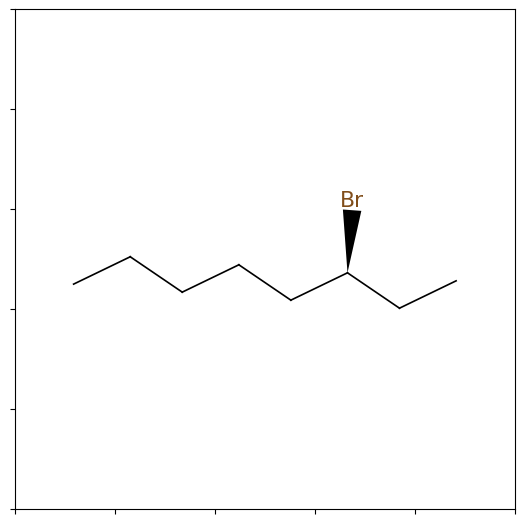

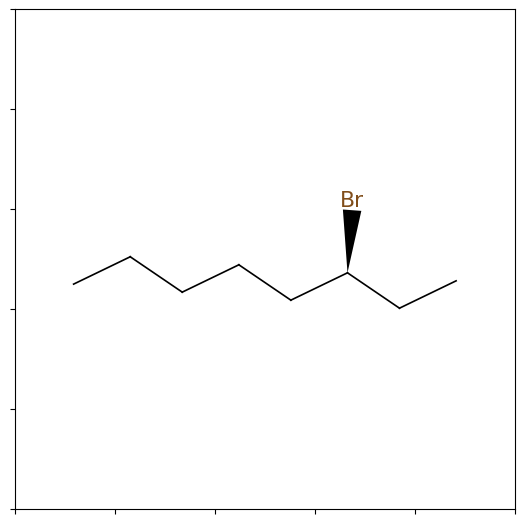

In [33]:
# We take two SMILES molecules from the ZINC database with nearly identical chemical structure, 
# the only difference being rooted in chiral specification (hence the additional ‘@‘ symbol). 
# This is a feature of molecules which indicates that there exists tetrahedral centres. 
# ‘@' tells us whether the neighbours of a molecule appear in a counter-clockwise order, 
# whereas ‘@@‘ indicates that the neighbours are ordered in a clockwise direction.

# Draw two chiral variants of the same molecule
m = Chem.MolFromSmiles('CCCCC[C@@H](Br)CC')
Draw.MolToMPL(m, size=(200, 200))

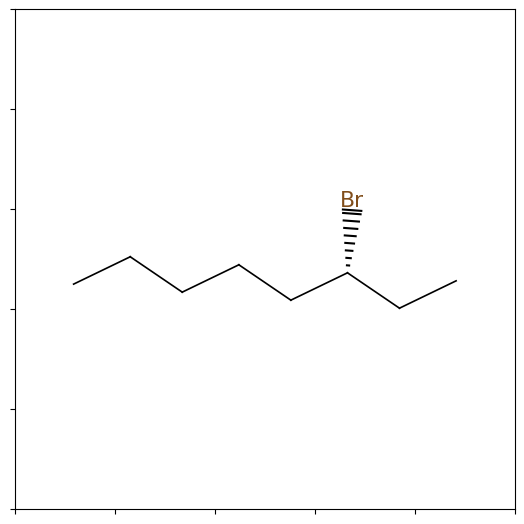

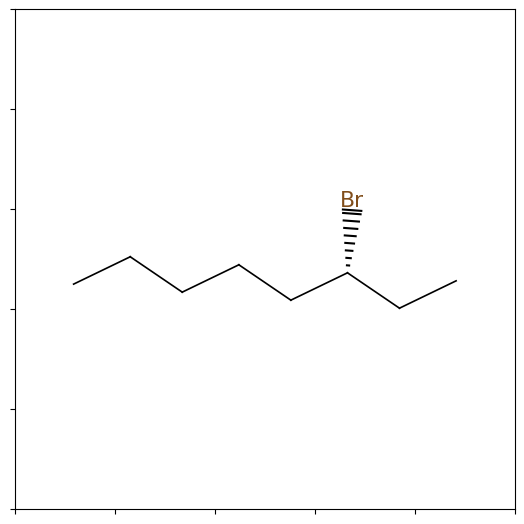

In [34]:
m = Chem.MolFromSmiles('CCCCC[C@H](Br)CC')
Draw.MolToMPL(m, size=(200, 200))

In [35]:
# The view visualizes attention as lines connecting the tokens being updated (left) with the tokens being attended to (right), 
# following the design of the figures above. 

# Color intensity reflects the attention weight; 
# weights close to one show as very dark lines, 
# while weights close to zero appear as faint lines or are not visible at all. 

# The user may highlight a particular SMILES character to see the attention from that token only. 
# This visualization is called the attention-head view. 

In [36]:
 # Attention head view
model_version = 'seyonec/PubChem10M_SMILES_BPE_450k'
model = RobertaModel.from_pretrained(model_version, output_attentions=True)
tokenizer = RobertaTokenizer.from_pretrained(model_version)
 
sentence_a = "CCCCC[C@@H](Br)CC"
sentence_b = "CCCCC[C@H](Br)CC"
inputs = tokenizer.encode_plus(
    sentence_a, sentence_b, return_tensors='pt', add_special_tokens=True,
)
input_ids = inputs['input_ids']
attention = model(input_ids)[-1]
input_id_list = input_ids[0].tolist()
tokens = tokenizer.convert_ids_to_tokens(input_id_list)
# call_html()
head_view(attention, tokens)

<IPython.core.display.Javascript object>

In [37]:
print("What is Transfer Learning, and how does ChemBERTa utilize it?")

print('''

Transfer learning is a research problem in machine learning that focuses on 
storing knowledge gained while solving one problem and applying it to a different but related problem .

By pre-training directly on SMILES strings, and teaching ChemBERTa to recognize masked tokens in each string, 
the model learns a strong molecular representation. 

We then can take this model, trained on a structural chemistry task, 
and apply it to a suite of classification tasks in the MoleculeNet suite, from Tox21 to BBBP!

''')

What is Transfer Learning, and how does ChemBERTa utilize it?


Transfer learning is a research problem in machine learning that focuses on 
storing knowledge gained while solving one problem and applying it to a different but related problem .

By pre-training directly on SMILES strings, and teaching ChemBERTa to recognize masked tokens in each string, 
the model learns a strong molecular representation. 

We then can take this model, trained on a structural chemistry task, 
and apply it to a suite of classification tasks in the MoleculeNet suite, from Tox21 to BBBP!




In [38]:
print('''

Our fine-tuning dataset, ClinTox, consists of qualitative data of drugs approved by the FDA and 
those that have failed clinical trials for toxicity reasons.

The ClinTox dataset consists of 1478 binary labels for toxicity, 
using the SMILES representations for identifying molecules. 

The computational models produced from the dataset could become decision-making tools 
for government agencies in determining which drugs are of the greatest potential concern to human health. 

Additionally, these models can act as drug screening tools in the drug discovery pipelines for toxicity.

''')



Our fine-tuning dataset, ClinTox, consists of qualitative data of drugs approved by the FDA and 
those that have failed clinical trials for toxicity reasons.

The ClinTox dataset consists of 1478 binary labels for toxicity, 
using the SMILES representations for identifying molecules. 

The computational models produced from the dataset could become decision-making tools 
for government agencies in determining which drugs are of the greatest potential concern to human health. 

Additionally, these models can act as drug screening tools in the drug discovery pipelines for toxicity.




In [39]:
print('''

Fine-tuning on ClinTox — loads the scaffold-split ClinTox data via load_molnet_dataset from bert-loves-chemistry. Then:

Model A — BPE-tokenized ChemBERTa (seyonec/PubChem10M_SMILES_BPE_396_250), 
10 epochs, 
fine-tuned with HuggingFace Trainer, 
evaluated with accuracy/AUPRC/AUROC, 
plus a single-molecule prediction on C1=C(C(=O)NC(=O)N1)F.

Model B — SmilesTokenizer ChemBERTa (seyonec/SMILES_tokenized_PubChem_shard00_160k), 
15 epochs, 
same Trainer recipe, 
same evaluation and prediction.

''')



Fine-tuning on ClinTox — loads the scaffold-split ClinTox data via load_molnet_dataset from bert-loves-chemistry. Then:

Model A — BPE-tokenized ChemBERTa (seyonec/PubChem10M_SMILES_BPE_396_250), 
10 epochs, 
fine-tuned with HuggingFace Trainer, 
evaluated with accuracy/AUPRC/AUROC, 
plus a single-molecule prediction on C1=C(C(=O)NC(=O)N1)F.

Model B — SmilesTokenizer ChemBERTa (seyonec/SMILES_tokenized_PubChem_shard00_160k), 
15 epochs, 
same Trainer recipe, 
same evaluation and prediction.




In [40]:
# ---------------------------------------------------------------------------
# 3. Fine-tuning on ClinTox
# ---------------------------------------------------------------------------
# Run once from a shell:
# %cd /content/bert-loves-chemistry
# !wget https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/vocab.txt
 
import os
import numpy as np
import pandas as pd
from typing import List
 
from deepchem.molnet import (
    load_bbbp, load_clearance, load_clintox, load_delaney,
    load_hiv, load_qm7, load_tox21,
)
from rdkit import Chem
 
# MolNet dataloader from bert-loves-chemistry
from chemberta.utils.molnet_dataloader import (
    load_molnet_dataset, write_molnet_dataset_for_chemprop,
)


In [41]:
 # Scaffold split of ClinTox
tasks, (train_df, valid_df, test_df), transformers = load_molnet_dataset("clintox", tasks_wanted=None,)
 
print("Train Dataset: {}".format(train_df.shape))
print("Eval Dataset:  {}".format(valid_df.shape))
print("TEST Dataset:  {}".format(test_df.shape))

'split' is deprecated.  Use 'splitter' instead.


Using tasks ['CT_TOX'] from available tasks for clintox: ['FDA_APPROVED', 'CT_TOX']
Train Dataset: (1182, 2)
Eval Dataset:  (148, 2)
TEST Dataset:  (148, 2)


In [42]:
train_df

,text,labels
0,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B(O)O,0
1,O=C(NCC(O)CO)c1c(I)c(C(=O)NCC(O)CO)c(I)c(N(CCO...,1
2,Clc1cc(Cl)c(OCC#CI)cc1Cl,1
3,N#Cc1cc(NC(=O)C(=O)[O-])c(Cl)c(NC(=O)C(=O)[O-])c1,1
4,NS(=O)(=O)c1cc(Cl)c(Cl)c(S(N)(=O)=O)c1,1
...,...,...
1177,CC(C[NH2+]C1CCCCC1)OC(=O)c1ccccc1,1
1178,CC(C(=O)[O-])c1ccc(C(=O)c2cccs2)cc1,1
1179,CC(c1cc2ccccc2s1)N(O)C(N)=O,1
1180,CC(O)C(CO)NC(=O)C1CSSCC(NC(=O)C([NH3+])Cc2cccc...,1


In [43]:
valid_df

,text,labels
0,CC(C)OC(=O)CCC/C=C\C[C@@H]1[C@@H](/C=C/[C@@H](...,1
1,CC(C)Nc1cccnc1N1CCN(C(=O)c2cc3cc(NS(C)(=O)=O)c...,1
2,CC(C)n1c(/C=C/[C@H](O)C[C@H](O)CC(=O)[O-])c(-c...,1
3,CC(C)COCC(CN(Cc1ccccc1)c1ccccc1)[NH+]1CCCC1,1
4,CSCC[C@H](NC(=O)[C@H](Cc1c[nH]c2ccccc12)NC(=O)...,1
...,...,...
143,C[C@H](OC(=O)c1ccccc1)C1=CCC23OCC[NH+](C)CC12C...,1
144,C[C@@H](c1ncncc1F)[C@](O)(Cn1cncn1)c1ccc(F)cc1F,1
145,CC(C)C[C@@H](NC(=O)[C@H](C)NC(=O)CNC(=O)[C@@H]...,1
146,C[C@H](O)[C@H](O)[C@H]1CNc2[nH]c(N)nc(=O)c2N1,1


In [44]:
test_df

,text,labels
0,C[NH+]1C[C@H](C(=O)N[C@]2(C)O[C@@]3(O)[C@@H]4C...,1
1,C[C@]1(Cn2ccnn2)[C@H](C(=O)[O-])N2C(=O)C[C@H]2...,1
2,C[NH+]1CCC[C@@H]1CCO[C@](C)(c1ccccc1)c1ccc(Cl)cc1,1
3,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,1
4,OC[C@H]1O[C@@H](n2cnc3c2NC=[NH+]C[C@H]3O)C[C@@...,1
...,...,...
143,O=C1O[C@H]([C@@H](O)CO)C([O-])=C1O,1
144,C#CCC(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)N[C@@H]...,1
145,C#CC[NH2+][C@@H]1CCc2ccccc21,1
146,[H]/[NH+]=C(\N)c1ccc(OCCCCCOc2ccc(/C(N)=[NH+]/...,1


In [45]:
# To compare tokenizers, we pretrained an identical model tokenized using this novel tokenizer, on the PubChem-1M set. 
# The pretrained model was evaluated on the BBBP and Tox21 in the paper. 
# We found that the SmilesTokenizer narrowly outperformed the BPE algorithm.

In [46]:
# ---------- Model A: BPE-tokenized ChemBERTa (PubChem-10M) -----------------

import numpy as np
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
)
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score

MODEL_NAME = "seyonec/PubChem10M_SMILES_BPE_396_250"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

def to_hf(df):
    ds = Dataset.from_pandas(df.rename(columns={"text": "smiles", "labels": "label"})[["smiles", "label"]])
    return ds.map(lambda x: tokenizer(x["smiles"], truncation=True, padding="max_length", max_length=128), batched=True)

train_ds = to_hf(train_df)
valid_ds = to_hf(valid_df)
test_ds  = to_hf(test_df)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    return {
        "accuracy": accuracy_score(labels, preds),
        "auprc":    average_precision_score(labels, probs),
        "auroc":    roc_auc_score(labels, probs),
    }

args = TrainingArguments(
    output_dir="./BPE_PubChem_10M_ClinTox_run",
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    report_to="none",     # set to "wandb" if you want it
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    compute_metrics=compute_metrics,
)
trainer.train()
print(trainer.evaluate(test_ds))

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/PubChem10M_SMILES_BPE_396_250 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/1182 [00:00<?, ? examples/s]

Map:   0%|          | 0/148 [00:00<?, ? examples/s]

Map:   0%|          | 0/148 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Auprc,Auroc
1,0.275100,0.206460,0.959459,0.989388,0.826291
2,0.186800,0.115285,0.972973,0.996284,0.920188
3,0.151700,0.170888,0.959459,0.995190,0.896714
4,0.072200,0.183761,0.959459,0.994713,0.889671
5,0.065800,0.171116,0.952703,0.994514,0.888498
6,0.079000,0.171451,0.952703,0.995176,0.900235
7,0.051600,0.251005,0.959459,0.994444,0.886150
8,0.042300,0.184943,0.952703,0.995175,0.899061
9,0.029200,0.208442,0.952703,0.995263,0.899061
10,0.047700,0.206097,0.952703,0.995321,0.900235


{'eval_loss': 0.29734906554222107, 'eval_accuracy': 0.9459459459459459, 'eval_auprc': 0.9877025431510937, 'eval_auroc': 0.8481215027977618, 'eval_runtime': 0.399, 'eval_samples_per_second': 370.917, 'eval_steps_per_second': 47.618, 'epoch': 10.0}


In [47]:
# Single-molecule prediction (expected label: 1 = failed clinical trials)
smi = "C1=C(C(=O)NC(=O)N1)F"
inputs = tokenizer(smi, return_tensors="pt", truncation=True, padding=True).to(model.device)
with torch.no_grad():
    logits = model(**inputs).logits
probs = torch.softmax(logits, dim=-1)
pred  = int(torch.argmax(logits, dim=-1))
print("Prediction:", pred)
print("Logits:", logits.cpu().numpy())
print("Probs:",  probs.cpu().numpy())

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Prediction: 1
Logits: [[-4.3047686  4.038333 ]]
Probs: [[2.3797627e-04 9.9976200e-01]]


In [48]:
train_ds = to_hf(train_df)
print(train_ds)

Map:   0%|          | 0/1182 [00:00<?, ? examples/s]

Dataset({
    features: ['smiles', 'label', 'input_ids', 'attention_mask'],
    num_rows: 1182
})


In [49]:
valid_ds = to_hf(valid_df)
print(valid_ds)

Map:   0%|          | 0/148 [00:00<?, ? examples/s]

Dataset({
    features: ['smiles', 'label', 'input_ids', 'attention_mask'],
    num_rows: 148
})


In [50]:
test_ds  = to_hf(test_df)
print(test_ds)

Map:   0%|          | 0/148 [00:00<?, ? examples/s]

Dataset({
    features: ['smiles', 'label', 'input_ids', 'attention_mask'],
    num_rows: 148
})


In [51]:
model

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(52000, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (

In [52]:
print("Benchmarking Smiles-Tokenizer ChemBERTa models on ClinTox")

Benchmarking Smiles-Tokenizer ChemBERTa models on ClinTox


In [53]:
# ---------- Model B: SmilesTokenizer ChemBERTa (PubChem shard00) -----------
import numpy as np
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
)
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score

MODEL_NAME = "seyonec/SMILES_tokenized_PubChem_shard00_160k"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
print(tokenizer)

# Convert pandas → HF Dataset and tokenize
def to_hf(df):
    ds = Dataset.from_pandas(
        df.rename(columns={"text": "smiles", "labels": "label"})[["smiles", "label"]]
    )
    return ds.map(
        lambda x: tokenizer(
            x["smiles"], truncation=True, padding="max_length", max_length=128,
        ),
        batched=True,
    )

train_ds = to_hf(train_df)
valid_ds = to_hf(valid_df)
test_ds  = to_hf(test_df)

# Metrics: accuracy, AUPRC, AUROC
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    return {
        "accuracy": accuracy_score(labels, preds),
        "auprc":    average_precision_score(labels, probs),
        "auroc":    roc_auc_score(labels, probs),
    }

args = TrainingArguments(
    output_dir="./SmilesTokenizer_PubChem_10M_ClinTox_run",
    num_train_epochs=15,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",       # evaluate at the end of each epoch
    save_strategy="no",          # mirrors simpletransformers' no_save=True
    logging_steps=50,
    report_to="none",            # set to "wandb" if you want W&B
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    compute_metrics=compute_metrics,
)
trainer.train()

# Final evaluation on the held-out test set
print("Test metrics:", trainer.evaluate(test_ds))



Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/SMILES_tokenized_PubChem_shard00_160k and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaTokenizerFast(name_or_path='seyonec/SMILES_tokenized_PubChem_shard00_160k', vocab_size=591, model_max_length=514, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	11: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	12: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	13: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	14: AddedToken("[MASK]", rstrip=False, lstrip=True, single_word=False, normalized=False, special=True),
	591: AddedToken("<s>", rstrip=False, lstrip=False, single_word=Fals

Map:   0%|          | 0/1182 [00:00<?, ? examples/s]

Map:   0%|          | 0/148 [00:00<?, ? examples/s]

Map:   0%|          | 0/148 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Auprc,Auroc
1,0.270400,0.212077,0.959459,0.988454,0.764085
2,0.238700,0.159430,0.959459,0.986886,0.775822
3,0.205400,0.191968,0.939189,0.987481,0.767606
4,0.130500,0.231694,0.959459,0.987189,0.759390
5,0.137900,0.279520,0.898649,0.986608,0.772300
6,0.116400,0.421390,0.851351,0.987664,0.762911
7,0.130600,0.277302,0.952703,0.989239,0.791080
8,0.072100,0.226476,0.925676,0.991736,0.833333
9,0.071900,0.348032,0.885135,0.990085,0.803991
10,0.098700,0.274925,0.918919,0.991947,0.829812


Test metrics: {'eval_loss': 0.3749808669090271, 'eval_accuracy': 0.9324324324324325, 'eval_auprc': 0.9655149672757726, 'eval_auroc': 0.7334132693844924, 'eval_runtime': 0.4857, 'eval_samples_per_second': 304.741, 'eval_steps_per_second': 39.122, 'epoch': 15.0}


In [54]:
# Single-molecule prediction (expected label: 1 = failed clinical trials)
smi = "C1=C(C(=O)NC(=O)N1)F"
inputs = tokenizer(smi, return_tensors="pt", truncation=True, padding=True).to(model.device)
with torch.no_grad():
    logits = model(**inputs).logits
probs = torch.softmax(logits, dim=-1)
pred  = int(torch.argmax(logits, dim=-1))
print("Prediction:", pred)
print("Logits:", logits.cpu().numpy())
print("Probs:",  probs.cpu().numpy())

Prediction: 1
Logits: [[-4.2671227  4.7583666]]
Probs: [[1.2028939e-04 9.9987972e-01]]


In [55]:
# The code below gives errors : 

# Same error as before — you're hitting the original simpletransformers import chain again. 
# simpletransformers tries to import XLNetSequenceSummary from transformers, 
# which doesn't exist in your transformers 4.43.x.

# Fix: skip the simpletransformers cell entirely and run the Trainer-based Model B block.

In [56]:
# from simpletransformers.classification import ClassificationModel, ClassificationArgs
# import logging
 
# logging.basicConfig(level=logging.INFO)
# transformers_logger = logging.getLogger("transformers")
# transformers_logger.setLevel(logging.WARNING)

In [57]:
print('''
---------- Model A: BPE-tokenized ChemBERTa (PubChem-10M) -----------------
''')


---------- Model A: BPE-tokenized ChemBERTa (PubChem-10M) -----------------



In [58]:
# ---------- Model A: BPE-tokenized ChemBERTa (PubChem-10M) -----------------

# model = ClassificationModel(
#    'roberta',
#    'seyonec/PubChem10M_SMILES_BPE_396_250',
#    args={
#        'evaluate_each_epoch': True,
#        'evaluate_during_training_verbose': True,
#        'no_save': True,
#        'num_train_epochs': 10,
#        'auto_weights': True,
#    },
# )
# print(model.tokenizer)
 
# !wandb login   # optional
# !mkdir BPE_PubChem_10M_ClinTox_run
 
# model.train_model(
#    train_df,
#    eval_df=valid_df,
#    output_dir='/content/BPE_PubChem_10M_ClinTox_run',
#    args={'wandb_project': 'project-name'},
# )
 
# Evaluate
# import sklearn
# result, model_outputs, wrong_predictions = model.eval_model(
#         test_df, acc=sklearn.metrics.accuracy_score,
# )
# result, model_outputs, wrong_predictions = model.eval_model(
#        test_df, acc=sklearn.metrics.average_precision_score,
# )
 
# Single prediction (expected label: 1 = failed clinical trials)
# predictions, raw_outputs = model.predict(['C1=C(C(=O)NC(=O)N1)F'])
# print(predictions)
# print(raw_outputs)

In [59]:
# Another version of the code : Claude

In [60]:
print('''
---------- Model B: SmilesTokenizer ChemBERTa (PubChem shard00) -----------
''')


---------- Model B: SmilesTokenizer ChemBERTa (PubChem shard00) -----------



In [61]:
# ---------- Model B: SmilesTokenizer ChemBERTa (PubChem shard00) -----------
# model = ClassificationModel(
#    'roberta',
#    'seyonec/SMILES_tokenized_PubChem_shard00_160k',
#    args={
#        'evaluate_each_epoch': True,
#        'evaluate_during_training_verbose': True,
#        'no_save': True,
#        'num_train_epochs': 15,
#        'auto_weights': True,
#    },
# )
# print(model.tokenizer)
 
# !mkdir SmilesTokenizer_PubChem_10M_ClinTox_run
 
# model.train_model(
#    train_df,
#    eval_df=valid_df,
#    output_dir='/content/SmilesTokenizer_PubChem_10M_ClinTox_run',
#    args={'wandb_project': 'project-name'},
# )
 
# result, model_outputs, wrong_predictions = model.eval_model(
#         test_df, acc=sklearn.metrics.accuracy_score,
# )
# result, model_outputs, wrong_predictions = model.eval_model(
#         test_df, acc=sklearn.metrics.average_precision_score,
# )
 
# predictions, raw_outputs = model.predict(['C1=C(C(=O)NC(=O)N1)F'])
# print(predictions)
# print(raw_outputs)

In [62]:
from chemberta.utils.molnet_dataloader import load_molnet_dataset

tasks, (train_df, valid_df, test_df), _ = load_molnet_dataset(
    "clintox", tasks_wanted=None,
)
print(train_df.shape, valid_df.shape, test_df.shape)

'split' is deprecated.  Use 'splitter' instead.


Using tasks ['CT_TOX'] from available tasks for clintox: ['FDA_APPROVED', 'CT_TOX']
(1182, 2) (148, 2) (148, 2)


In [63]:
# =============================================================
# Token-visualization comparison: Model A (BPE) vs Model B (SmilesTokenizer)
# =============================================================
import hashlib
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from transformers import AutoTokenizer

# ---- 0. Load both tokenizers --------------------------------
MODEL_A = "seyonec/PubChem10M_SMILES_BPE_396_250"
MODEL_B = "seyonec/SMILES_tokenized_PubChem_shard00_160k"

tok_A = AutoTokenizer.from_pretrained(MODEL_A)
tok_B = AutoTokenizer.from_pretrained(MODEL_B)

print(f"Model A (BPE)             vocab size: {tok_A.vocab_size}")
print(f"Model B (SmilesTokenizer) vocab size: {tok_B.vocab_size}")

# A handful of chemically diverse SMILES for the per-molecule demos
SMILES_DEMO = [
    "CCCCC[C@@H](Br)CC",                        # chiral aliphatic
    "C1=CC=CC=C1",                              # benzene
    "C1=C(C(=O)NC(=O)N1)F",                     # 5-fluorouracil
    "CC(=O)Oc1ccccc1C(=O)O",                    # aspirin
    "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",             # caffeine
]


# =============================================================
# 1. Plain side-by-side print
# =============================================================
print("\n" + "=" * 70)
print("1. Side-by-side tokenization")
print("=" * 70)
for smi in SMILES_DEMO:
    toks_a = tok_A.tokenize(smi)
    toks_b = tok_B.tokenize(smi)
    print(f"\nSMILES: {smi}")
    print(f"  Model A — BPE       ({len(toks_a):>2} tokens): {toks_a}")
    print(f"  Model B — SmilesTok ({len(toks_b):>2} tokens): {toks_b}")


# =============================================================
# 2. Token → ID mapping for one molecule
# =============================================================
def show_ids(tokenizer, smi, name):
    ids = tokenizer.encode(smi, add_special_tokens=True)
    toks = tokenizer.convert_ids_to_tokens(ids)
    print(f"\n{name} on {smi!r}")
    for t, i in zip(toks, ids):
        print(f"  {t:>12}  →  id {i}")

print("\n" + "=" * 70)
print("2. Token → ID mapping (aspirin)")
print("=" * 70)
show_ids(tok_A, "CC(=O)Oc1ccccc1C(=O)O", "Model A — BPE")
show_ids(tok_B, "CC(=O)Oc1ccccc1C(=O)O", "Model B — SmilesTokenizer")


# =============================================================
# 3. Color-coded inline HTML visualization
# =============================================================
def color_for(token):
    """Deterministic pastel background based on the token text."""
    h = int(hashlib.md5(token.encode()).hexdigest(), 16)
    return f"hsl({h % 360}, 70%, 80%)"

def render_tokens(tokenizer, smi, title):
    toks = tokenizer.tokenize(smi)
    spans = "".join(
        f'<span style="background:{color_for(t)};padding:2px 4px;'
        f'margin:1px;border-radius:3px;font-family:monospace">{t}</span>'
        for t in toks
    )
    return (
        f"<div style='margin:8px 0'><b>{title}</b> "
        f"({len(toks)} tokens)<br>{spans}</div>"
    )

html = "<h3>3. Color-coded token ribbons (Model A vs Model B)</h3>"
for smi in SMILES_DEMO:
    html += f"<div style='margin-top:14px'><i>SMILES:</i> <code>{smi}</code></div>"
    html += render_tokens(tok_A, smi, "Model A — BPE")
    html += render_tokens(tok_B, smi, "Model B — SmilesTokenizer")
display(HTML(html))



Model A (BPE)             vocab size: 7924
Model B (SmilesTokenizer) vocab size: 591

1. Side-by-side tokenization

SMILES: CCCCC[C@@H](Br)CC
  Model A — BPE       (10 tokens): ['CCCCC', '[', 'C', '@', '@', 'H', '](', 'Br', ')', 'CC']
  Model B — SmilesTok (11 tokens): ['C', 'C', 'C', 'C', 'C', 'C', '(', 'B', ')', 'C', 'C']

SMILES: C1=CC=CC=C1
  Model A — BPE       ( 9 tokens): ['C', '1', '=', 'CC', '=', 'CC', '=', 'C', '1']
  Model B — SmilesTok (11 tokens): ['C', '1', '=', 'C', 'C', '=', 'C', 'C', '=', 'C', '1']

SMILES: C1=C(C(=O)NC(=O)N1)F
  Model A — BPE       (17 tokens): ['C', '1', '=', 'C', '(', 'C', '(=', 'O', ')', 'NC', '(=', 'O', ')', 'N', '1', ')', 'F']
  Model B — SmilesTok (20 tokens): ['C', '1', '=', 'C', '(', 'C', '(', '=', 'O', ')', 'N', 'C', '(', '=', 'O', ')', 'N', '1', ')', 'F']

SMILES: CC(=O)Oc1ccccc1C(=O)O
  Model A — BPE       (13 tokens): ['CC', '(=', 'O', ')', 'Oc', '1', 'ccccc', '1', 'C', '(=', 'O', ')', 'O']
  Model B — SmilesTok (21 tokens): ['C', 'C', '('

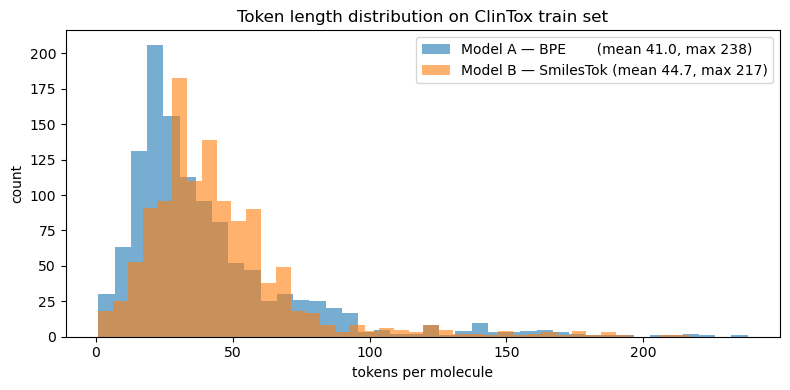


Model A — BPE       : mean=40.96  median=31  max=238
Model B — SmilesTok : mean=44.65  median=39  max=217


In [64]:

# =============================================================
# 4. Token-length distribution across the ClinTox train set
# =============================================================
def token_lens(tokenizer, df, col="text"):
    return np.array([len(tokenizer.tokenize(s)) for s in df[col]])

# Uses your train_df from the load_molnet_dataset call earlier in the notebook
lens_A = token_lens(tok_A, train_df)
lens_B = token_lens(tok_B, train_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lens_A, bins=40, alpha=0.6,
        label=f"Model A — BPE       (mean {lens_A.mean():.1f}, max {lens_A.max()})")
ax.hist(lens_B, bins=40, alpha=0.6,
        label=f"Model B — SmilesTok (mean {lens_B.mean():.1f}, max {lens_B.max()})")
ax.set_xlabel("tokens per molecule")
ax.set_ylabel("count")
ax.set_title("Token length distribution on ClinTox train set")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nModel A — BPE       : mean={lens_A.mean():.2f}  median={np.median(lens_A):.0f}  max={lens_A.max()}")
print(f"Model B — SmilesTok : mean={lens_B.mean():.2f}  median={np.median(lens_B):.0f}  max={lens_B.max()}")



In [65]:
# =============================================================
# 5a. Character-span offsets (BPE only — fast tokenizer)
# =============================================================
print("\n" + "=" * 70)
print("5. Character spans for each token (Model A only)")
print("=" * 70)

smi = SMILES_DEMO[0]
try:
    enc = tok_A(smi, return_offsets_mapping=True, add_special_tokens=False)
    print(f"\nModel A — BPE on {smi!r}")
    for tok_id, (a, b) in zip(enc["input_ids"], enc["offset_mapping"]):
        print(f"  {tok_A.decode([tok_id]):>10}  → chars [{a}:{b}] = {smi[a:b]!r}")
except (NotImplementedError, ValueError) as e:
    print(f"Offset mapping not available for Model A: {e}")

print(
    "\nModel B — SmilesTokenizer is a slow tokenizer; "
    "offset_mapping is not supported. The token text alone is the visualization."
)


5. Character spans for each token (Model A only)

Model A — BPE on 'CCCCC[C@@H](Br)CC'
       CCCCC  → chars [0:5] = 'CCCCC'
           [  → chars [5:6] = '['
           C  → chars [6:7] = 'C'
           @  → chars [7:8] = '@'
           @  → chars [8:9] = '@'
           H  → chars [9:10] = 'H'
          ](  → chars [10:12] = ']('
          Br  → chars [12:14] = 'Br'
           )  → chars [14:15] = ')'
          CC  → chars [15:17] = 'CC'

Model B — SmilesTokenizer is a slow tokenizer; offset_mapping is not supported. The token text alone is the visualization.


In [66]:
# =============================================================
# 5b. Character spans for each token (Model B — manual offsets)
# =============================================================
print("\n" + "=" * 70)
print("5b. Character spans for each token (Model B — SmilesTokenizer)")
print("=" * 70)

def smilestokenizer_offsets(tokenizer, smi):
    """
    Recover character spans for a slow SmilesTokenizer by sequentially
    matching each token to the next occurrence in the SMILES string.
    Skips special tokens that aren't substrings of `smi`.
    """
    tokens = tokenizer.tokenize(smi)
    offsets = []
    cursor = 0
    for tok in tokens:
        # Skip any HF special tokens (shouldn't appear with add_special_tokens=False,
        # but be defensive)
        if tok in tokenizer.all_special_tokens:
            offsets.append((cursor, cursor))
            continue
        idx = smi.find(tok, cursor)
        if idx == -1:
            # Token text didn't match the SMILES — shouldn't happen for
            # a well-formed SmilesTokenizer + valid SMILES, but bail safely.
            offsets.append((None, None))
            continue
        offsets.append((idx, idx + len(tok)))
        cursor = idx + len(tok)
    return tokens, offsets


smi = SMILES_DEMO[0]
tokens_b, offsets_b = smilestokenizer_offsets(tok_B, smi)

print(f"\nModel B — SmilesTokenizer on {smi!r}")
for tok, (a, b) in zip(tokens_b, offsets_b):
    if a is None:
        print(f"  {tok:>10}  → (no match)")
    else:
        print(f"  {tok:>10}  → chars [{a}:{b}] = {smi[a:b]!r}")


5b. Character spans for each token (Model B — SmilesTokenizer)

Model B — SmilesTokenizer on 'CCCCC[C@@H](Br)CC'
           C  → chars [0:1] = 'C'
           C  → chars [1:2] = 'C'
           C  → chars [2:3] = 'C'
           C  → chars [3:4] = 'C'
           C  → chars [4:5] = 'C'
           C  → chars [6:7] = 'C'
           (  → chars [11:12] = '('
           B  → chars [12:13] = 'B'
           )  → chars [14:15] = ')'
           C  → chars [15:16] = 'C'
           C  → chars [16:17] = 'C'


In [67]:
def show_offsets(tokenizer, smi, name, manual=False):
    print(f"\n{name} on {smi!r}")
    if manual:
        tokens, offs = smilestokenizer_offsets(tokenizer, smi)
        for t, (a, b) in zip(tokens, offs):
            print(f"  {t:>12}  → chars [{a}:{b}] = {smi[a:b]!r}")
    else:
        enc = tokenizer(smi, return_offsets_mapping=True, add_special_tokens=False)
        for tid, (a, b) in zip(enc["input_ids"], enc["offset_mapping"]):
            print(f"  {tokenizer.decode([tid]):>12}  → chars [{a}:{b}] = {smi[a:b]!r}")

show_offsets(tok_A, smi, "Model A — BPE",            manual=False)
show_offsets(tok_B, smi, "Model B — SmilesTokenizer", manual=True)


Model A — BPE on 'CCCCC[C@@H](Br)CC'
         CCCCC  → chars [0:5] = 'CCCCC'
             [  → chars [5:6] = '['
             C  → chars [6:7] = 'C'
             @  → chars [7:8] = '@'
             @  → chars [8:9] = '@'
             H  → chars [9:10] = 'H'
            ](  → chars [10:12] = ']('
            Br  → chars [12:14] = 'Br'
             )  → chars [14:15] = ')'
            CC  → chars [15:17] = 'CC'

Model B — SmilesTokenizer on 'CCCCC[C@@H](Br)CC'
             C  → chars [0:1] = 'C'
             C  → chars [1:2] = 'C'
             C  → chars [2:3] = 'C'
             C  → chars [3:4] = 'C'
             C  → chars [4:5] = 'C'
             C  → chars [6:7] = 'C'
             (  → chars [11:12] = '('
             B  → chars [12:13] = 'B'
             )  → chars [14:15] = ')'
             C  → chars [15:16] = 'C'
             C  → chars [16:17] = 'C'


In [68]:
print('''

Model A — BPE Tokenizer (Byte-Pair Encoding)

Model A learns its tokens statistically from the large PubChem pretraining corpus. The tokenizer repeatedly merges character pairs that appear very frequently together in the training data.

As a result, common SMILES patterns become compressed into larger tokens:

CCCCC may become a single token because long carbon chains occur extremely often.
]( may also become a merged token because the close-bracket/open-parenthesis pattern is highly frequent in SMILES syntax.
CC frequently appears as one token for the same reason.

However, stereochemical annotations such as:

[C@@H]

often remain fragmented into individual characters:

[, C, @, @, H, ]

because chiral specifications are comparatively rare in the training data and therefore never became high-frequency merge candidates.

In other words:

BPE is frequency-driven, not chemistry-driven.

It learns statistical regularities rather than explicit chemical structure.

Model B — SmilesTokenizer

Model B uses a chemistry-aware regular-expression tokenizer designed specifically for molecular syntax.

Instead of merging tokens statistically, it explicitly preserves chemically meaningful units:

each atom becomes a token
each bond becomes a token
each ring index becomes a token
each parenthesis becomes a token
stereochemical markers are preserved intentionally

For example, a carbon chain like:

CCCCC

is tokenized as:

C  C  C  C  C

rather than compressed into a single token.

The tokenizer does not care how common a pattern is in the corpus.

Instead:

SmilesTokenizer is chemistry-driven rather than frequency-driven.

This makes the tokenization more interpretable from a chemical perspective.

The unusual behavior in the offsets

The output from Model B contains several apparent gaps in the character offsets:

C → [4:5]    ← position 5 ('[') skipped
C → [6:7]    ← positions 7–10 ('@@H]') skipped
( → [11:12]
B → [12:13]  ← position 13 ('r') skipped

At first glance, this looks incorrect, but the most likely explanation is related to vocabulary handling.

The SmilesTokenizer probably did generate proper tokens for components such as:

[
@@
H
]
Br

However, during post-processing:

some tokens may have been filtered out by the smilestokenizer_offsets() helper function,
some may have been treated as special tokens,
or some may have been mapped to:
[UNK]

(out-of-vocabulary / unknown token)

because the model uses a relatively small vocabulary (~591 tokens).

When [UNK] tokens appear, the offset-mapping function can no longer reliably align them back to exact SMILES substrings, which creates the apparent gaps in the offset ranges.

So the strange offsets are probably not a failure of the tokenizer itself, but rather a limitation of:

offset reconstruction,
unknown-token handling,
or vocabulary coverage.

''')



Model A — BPE Tokenizer (Byte-Pair Encoding)

Model A learns its tokens statistically from the large PubChem pretraining corpus. The tokenizer repeatedly merges character pairs that appear very frequently together in the training data.

As a result, common SMILES patterns become compressed into larger tokens:

CCCCC may become a single token because long carbon chains occur extremely often.
]( may also become a merged token because the close-bracket/open-parenthesis pattern is highly frequent in SMILES syntax.
CC frequently appears as one token for the same reason.

However, stereochemical annotations such as:

[C@@H]

often remain fragmented into individual characters:

[, C, @, @, H, ]

because chiral specifications are comparatively rare in the training data and therefore never became high-frequency merge candidates.

In other words:

BPE is frequency-driven, not chemistry-driven.

It learns statistical regularities rather than explicit chemical structure.

Model B — SmilesTokeniz

Test accuracy: 0.9324

               precision    recall  f1-score   support

non-toxic (0)     0.3333    0.1111    0.1667         9
    toxic (1)     0.9448    0.9856    0.9648       139

     accuracy                         0.9324       148
    macro avg     0.6391    0.5484    0.5657       148
 weighted avg     0.9076    0.9324    0.9163       148



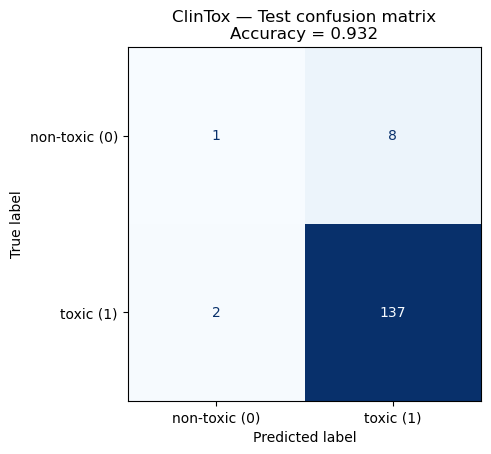

In [69]:
# =============================================================
# Confusion matrix using the model directly (no trainer needed)
# =============================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, classification_report,
)

device = model.device          # whatever device the model is on
model.eval()

# Build a simple DataLoader over the already-tokenized test_ds
def collate(batch):
    return {
        "input_ids":      torch.tensor([b["input_ids"]      for b in batch]),
        "attention_mask": torch.tensor([b["attention_mask"] for b in batch]),
        "labels":         torch.tensor([b["label"]          for b in batch]),
    }

loader = DataLoader(test_ds, batch_size=16, collate_fn=collate)

all_logits, all_labels = [], []
with torch.no_grad():
    for batch in loader:
        logits = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
        ).logits
        all_logits.append(logits.cpu().numpy())
        all_labels.append(batch["labels"].numpy())

logits = np.concatenate(all_logits, axis=0)
y_true = np.concatenate(all_labels, axis=0)
y_pred = np.argmax(logits, axis=-1)

# Metrics
acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {acc:.4f}\n")
print(classification_report(
    y_true, y_pred,
    target_names=["non-toxic (0)", "toxic (1)"],
    digits=4,
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["non-toxic (0)", "toxic (1)"],
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"ClinTox — Test confusion matrix\nAccuracy = {acc:.3f}")
plt.tight_layout()
plt.show()

In [70]:
print("CLS token : the role the [CLS] (or in RoBERTa-based models like ChemBERTa, <s>) token plays.")

CLS token : the role the [CLS] (or in RoBERTa-based models like ChemBERTa, <s>) token plays.


In [71]:
# When you tokenize a SMILES, the tokenizer prepends a special <s> (or [CLS]) token to the sequence before passing it to the model. 
# For example, CC(=O)O becomes <s> C C ( = O ) O </s> (with </s> / [SEP] at the end). 
# This special token has its own learned embedding, just like any other token in the vocabulary.

# Why it's the "whole molecule" representation
# During pretraining (masked language modeling on PubChem SMILES) and again during fine-tuning, 
# every transformer layer applies self-attention across all tokens in the sequence. 

# The <s> token sits at position 0 and attends to every other token in the molecule at every layer. 
# Because the classification head is wired specifically to the <s> output, 
# gradients during training push the model to pack a useful summary of the whole sequence into that one position. 
# By the end of training, the <s> hidden state has learned to be a fixed-size vector that summarizes the entire molecule.

# So when people say "ChemBERTa embedding of a molecule" they almost always mean: 
# feed the SMILES through the encoder, take the final-layer hidden state at position 0, 
# and treat that 768-dim (or 384-dim, depending on the variant) vector as the molecule's embedding.

In [72]:
print("How to extract it explicitly:")

How to extract it explicitly:


In [73]:
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained("seyonec/PubChem10M_SMILES_BPE_396_250")
encoder   = AutoModel.from_pretrained("seyonec/PubChem10M_SMILES_BPE_396_250")
encoder.eval()

smi = "CC(=O)Oc1ccccc1C(=O)O"  # aspirin
inputs = tokenizer(smi, return_tensors="pt")
with torch.no_grad():
    out = encoder(**inputs)

# Three common ways to get a molecule-level vector:
cls_embedding   = out.last_hidden_state[:, 0, :]    # <s> / [CLS] token  ← the standard one
pooled_output   = out.pooler_output                 # tanh-projected CLS (if the model has a pooler)
mean_embedding  = out.last_hidden_state.mean(dim=1) # average over all tokens (alternative)

print(cls_embedding.shape)  # torch.Size([1, 384]) for the 396_250 checkpoint

torch.Size([1, 768])


In [74]:
print("Embedding (first 10 dims):", cls_embedding[0, :10].numpy())
print(cls_embedding)

Embedding (first 10 dims): [-0.5961489  -0.8314597   1.0983299  -1.5396408  -0.40846533  1.3829589
  0.4382601  -0.8852384  -0.59890705  0.01624759]
tensor([[-5.9615e-01, -8.3146e-01,  1.0983e+00, -1.5396e+00, -4.0847e-01,
          1.3830e+00,  4.3826e-01, -8.8524e-01, -5.9891e-01,  1.6248e-02,
          1.0368e-02, -1.0736e+00,  2.8708e-01,  4.4282e-01,  1.1948e-01,
         -3.8413e-02,  5.9140e-01,  3.2045e-01,  1.0345e-01,  1.6526e+00,
         -1.4228e+00, -2.0803e+00, -3.1710e-02, -8.9442e-02,  2.1416e+00,
          4.5399e-01, -2.8442e-01, -2.9068e+00, -1.3346e-01,  1.4842e+00,
         -5.7145e-01, -8.1242e-01, -8.6514e-01,  1.3598e+00,  1.8339e+00,
         -9.4830e-01,  4.9837e-01, -1.4731e+00,  9.8284e-01, -1.0692e+00,
         -1.1425e+00,  1.2376e+00,  6.9947e-01, -2.9849e-01, -2.8412e-01,
          4.3047e-01,  1.4892e+00, -5.7687e-01,  2.8145e-01, -6.0945e-01,
         -8.3646e-01, -4.8032e-01, -7.7831e-01, -1.0441e-01, -2.0809e+00,
         -4.1598e-02,  1.0487e+00,  1

In [75]:
# Different ChemBERTa checkpoints have different embedding dimensions — PubChem10M_SMILES_BPE_396_250 uses 384-dim, 
# while DeepChem/ChemBERTa-77M-MTR uses 384-dim too, but some variants use 768-dim. 
# Check model.config.hidden_size if you're not sure.

In [76]:
print('''

The CLS token works because it was trained to attend across the whole sequence. 
For some tasks (especially molecular similarity search), mean-pooling the non-padding tokens gives slightly better results

''')



The CLS token works because it was trained to attend across the whole sequence. 
For some tasks (especially molecular similarity search), mean-pooling the non-padding tokens gives slightly better results




In [77]:
import numpy as np
import torch
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
encoder.to(device).eval()

def cls_embeddings(smiles_list, batch_size=32, max_length=128):
    """Return a (N, hidden_size) numpy array of CLS embeddings."""
    all_embs = []
    for i in range(0, len(smiles_list), batch_size):
        batch = smiles_list[i:i + batch_size]
        enc = tokenizer(
            batch, return_tensors="pt",
            padding=True, truncation=True, max_length=max_length,
        ).to(device)
        with torch.no_grad():
            out = encoder(**enc)
        cls = out.last_hidden_state[:, 0, :].cpu().numpy()
        all_embs.append(cls)
    return np.concatenate(all_embs, axis=0)

# Use the SMILES column of your ClinTox dataframe
train_embs = cls_embeddings(train_df["text"].tolist())
test_embs  = cls_embeddings(test_df["text"].tolist())

print("Train embeddings shape:", train_embs.shape)  # e.g. (1182, 384)
print("Test  embeddings shape:", test_embs.shape)   # e.g. (148,  384)

Train embeddings shape: (1182, 768)
Test  embeddings shape: (148, 768)


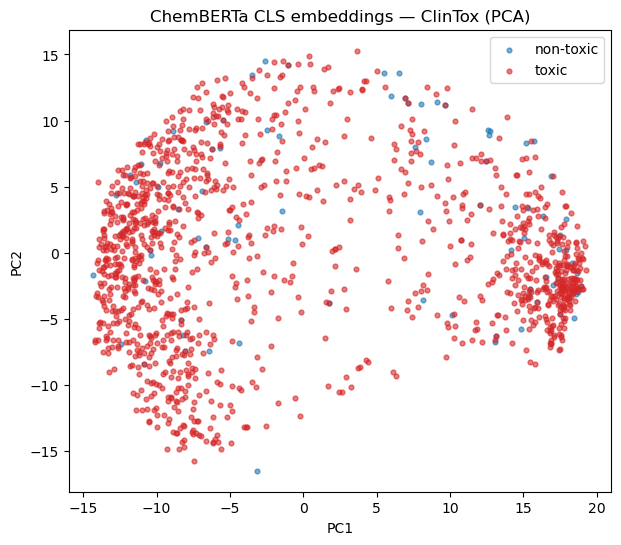

In [78]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Combine train + test for one consistent projection
all_embs   = np.vstack([train_embs, test_embs])
all_labels = np.concatenate([train_df["labels"].values, test_df["labels"].values])

# 2D projection
proj = PCA(n_components=2).fit_transform(all_embs)

plt.figure(figsize=(7, 6))
for cls, name, color in [(0, "non-toxic", "tab:blue"),
                         (1, "toxic",     "tab:red")]:
    mask = all_labels == cls
    plt.scatter(proj[mask, 0], proj[mask, 1], s=12, alpha=0.6,
                label=name, color=color)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
plt.title("ChemBERTa CLS embeddings — ClinTox (PCA)")
plt.show()

/home/tanasa/anaconda3/envs/liana_py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


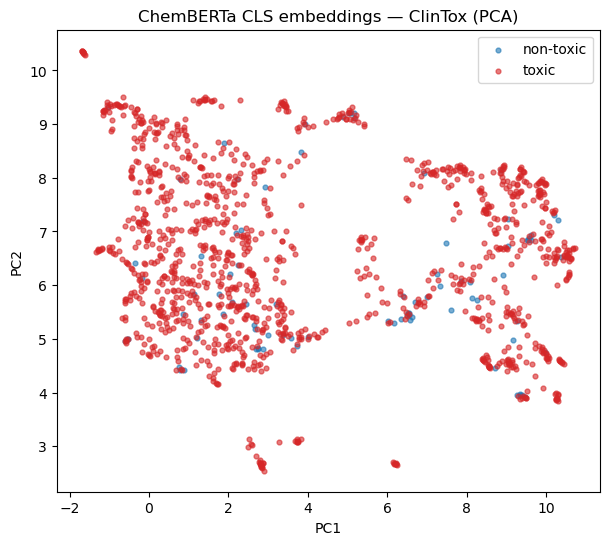

In [79]:
import umap
proj = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(all_embs)
# then the same scatter-plot code as above

proj

plt.figure(figsize=(7, 6))
for cls, name, color in [(0, "non-toxic", "tab:blue"),
                         (1, "toxic",     "tab:red")]:
    mask = all_labels == cls
    plt.scatter(proj[mask, 0], proj[mask, 1], s=12, alpha=0.6,
                label=name, color=color)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
plt.title("ChemBERTa CLS embeddings — ClinTox (PCA)")
plt.show()

In [80]:
# To build a table of DRUG INFO + CLS EMBEDDINGS

In [81]:
# The ClinTox dataframe from load_molnet_dataset only gives you SMILES + labels — no molecule names. So we need to either:

# Use SMILES as the identifier (works, unique per molecule, fast), or
# Look up real names via PubChem (more useful but slow and needs network).

In [82]:
print('''

CLINTOX database :

Input format

Each sample looks conceptually like:

SMILES	Label
CCO	0
CCN(CC)CC	1

Where:

the SMILES string is the molecular representation
the label indicates toxicity outcome
The labels

ClinTox is usually treated as a binary classification problem.

Typical interpretation:

Label	Meaning
0	FDA-approved / lower toxicity concern
1	Failed clinical trials because of toxicity

So your ChemBERTa classifier predicts:

toxic vs non-toxic
unsafe vs safer compounds

''')



CLINTOX database :

Input format

Each sample looks conceptually like:

SMILES	Label
CCO	0
CCN(CC)CC	1

Where:

the SMILES string is the molecular representation
the label indicates toxicity outcome
The labels

ClinTox is usually treated as a binary classification problem.

Typical interpretation:

Label	Meaning
0	FDA-approved / lower toxicity concern
1	Failed clinical trials because of toxicity

So your ChemBERTa classifier predicts:

toxic vs non-toxic
unsafe vs safer compounds




In [83]:
# A script that does both: 
# writes one combined file (molecules_embeddings.parquet or .csv) 
# with mol_id, smiles, inchikey, name, split, label, and the embedding columns emb_0 … emb_383.

In [84]:
# =============================================================
# Build a single file with: name | SMILES | embedding (per molecule)
# =============================================================
import numpy as np
import pandas as pd
import torch
from rdkit import Chem
from rdkit.Chem.inchi import MolToInchiKey
from transformers import AutoTokenizer, AutoModel

# --- 1. Choose which model to take embeddings from ---
# Pretrained-only (no ClinTox fine-tuning):
MODEL_DIR = "seyonec/PubChem10M_SMILES_BPE_396_250"
# Or your fine-tuned model:
# MODEL_DIR = "./chemberta_clintox_modelA"

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
encoder   = AutoModel.from_pretrained(MODEL_DIR)

device = "cuda" if torch.cuda.is_available() else "cpu"
encoder.to(device).eval()

# --- 2. Compute CLS embeddings in batches ---
def cls_embeddings(smiles_list, batch_size=32, max_length=128):
    embs = []
    for i in range(0, len(smiles_list), batch_size):
        batch = smiles_list[i:i + batch_size]
        enc = tokenizer(
            batch, return_tensors="pt",
            padding=True, truncation=True, max_length=max_length,
        ).to(device)
        with torch.no_grad():
            out = encoder(**enc)
        embs.append(out.last_hidden_state[:, 0, :].cpu().numpy())
    return np.concatenate(embs, axis=0)

# --- 3. Walk the three splits, build a combined dataframe ---
def build_rows(df, split_name):
    smiles  = df["text"].tolist()
    labels  = df["labels"].tolist() if "labels" in df.columns else [None] * len(df)
    embs    = cls_embeddings(smiles)

    rows = []
    for i, (smi, lab, vec) in enumerate(zip(smiles, labels, embs)):
        mol = Chem.MolFromSmiles(smi)
        inchikey = MolToInchiKey(mol) if mol is not None else ""
        rows.append({
            "mol_id":   f"{split_name}_{i:04d}",
            "split":    split_name,
            "name":     "",            # filled later (PubChem lookup)
            "smiles":   smi,
            "inchikey": inchikey,
            "label":    lab,
            "embedding": vec,          # numpy array of shape (hidden_size,)
        })
    return rows

all_rows = (
    build_rows(train_df, "train")
    + build_rows(valid_df, "valid")
    + build_rows(test_df,  "test")
)
df_all = pd.DataFrame(all_rows)
print(f"Total molecules: {len(df_all)}")
print(f"Embedding dim: {df_all['embedding'].iloc[0].shape}")

[12:43:10] Invalid InChI prefix in generating InChI Key


Total molecules: 1478
Embedding dim: (768,)


In [85]:
df_all.iloc[[1, 4]]

,mol_id,split,name,smiles,inchikey,label,embedding
1,train_0001,train,,O=C(NCC(O)CO)c1c(I)c(C(=O)NCC(O)CO)c(I)c(N(CCO...,AMDBBAQNWSUWGN-UHFFFAOYSA-N,1,"[2.084501, 0.32149586, -0.29296297, -0.1507765..."
4,train_0004,train,,NS(=O)(=O)c1cc(Cl)c(Cl)c(S(N)(=O)=O)c1,GJQPMPFPNINLKP-UHFFFAOYSA-N,1,"[-2.1214838, -1.2163359, 1.0138307, -1.9581505..."


In [86]:
# Molecule 1

In [87]:
row = df_all.iloc[1]
print("mol_id   :", row["mol_id"])
print("split    :", row["split"])
print("name     :", row["name"])
print("SMILES   :", row["smiles"])
print("InChIKey :", row["inchikey"])
print("label    :", row["label"])
print("embedding shape :", row["embedding"].shape)
print("first 8 dims    :", row["embedding"][:8])

mol_id   : train_0001
split    : train
name     : 
SMILES   : O=C(NCC(O)CO)c1c(I)c(C(=O)NCC(O)CO)c(I)c(N(CCO)C(=O)CO)c1I
InChIKey : AMDBBAQNWSUWGN-UHFFFAOYSA-N
label    : 1
embedding shape : (768,)
first 8 dims    : [ 2.084501    0.32149586 -0.29296297 -0.15077658  0.22355789 -1.4706752
 -0.15890488 -0.02807245]


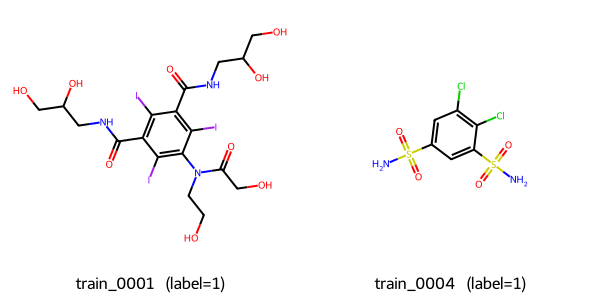

In [88]:
from rdkit import Chem
from rdkit.Chem import Draw

smiles_to_show = df_all.iloc[[1, 4]]["smiles"].tolist()
mols = [Chem.MolFromSmiles(s) for s in smiles_to_show]
legends = [
    f"{df_all.iloc[i]['mol_id']}  (label={df_all.iloc[i]['label']})"
    for i in [1, 4]
]
Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(300, 300), legends=legends)

In [89]:
import numpy as np
from numpy.linalg import norm

v1 = df_all.iloc[1]["embedding"]
v4 = df_all.iloc[4]["embedding"]

cosine_sim = v1 @ v4 / (norm(v1) * norm(v4))
euclidean  = norm(v1 - v4)

print(f"Cosine similarity: {cosine_sim:.4f}")
print(f"Euclidean dist  : {euclidean:.4f}")

Cosine similarity: 0.1790
Euclidean dist  : 35.5452


In [90]:
# https://github.com/SylwiaNowakowska/LLM_Fine_Tuning_Molecular_Properties